<a href="https://colab.research.google.com/github/DanielNazarioPro/CienciadeDados/blob/main/Analise_por_Continentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CÉLULA 1 — Imports (sem instalações, Colab já tem tudo)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:

# CÉLULA 2 — Carregar os CSVs (seus arquivos já estão no Colab)

# Faça upload dos dois arquivos via: Arquivos (ícone de pasta) > Upload
# Ou use: from google.colab import files; files.upload()
# Depois aponte os caminhos abaixo:

df_hist = pd.read_csv('/content/world_olympedia_olympics_game_medal_tally.csv')
df_p24  = pd.read_csv('/content/medals_total.csv')

print("Histórico:", df_hist.shape)
print(df_hist.head(3))
print("\nParis 2024:", df_p24.shape)
print(df_p24.head(3))

Histórico: (1807, 9)
   year               edition  edition_id        country country_noc  gold  \
0  1896  1896 Summer Olympics           1         Greece         GRE    10   
1  1900  1900 Summer Olympics           2         France         FRA    31   
2  1900  1900 Summer Olympics           2  United States         USA    20   

   silver  bronze  total  
0      18      19     47  
1      41      40    112  
2      13      15     48  

Paris 2024: (92, 7)
  country_code        country                country_long  Gold Medal  \
0          USA  United States    United States of America          40   
1          CHN          China  People's Republic of China          40   
2          JPN          Japan                       Japan          20   

   Silver Medal  Bronze Medal  Total  
0            44            42    126  
1            27            24     91  
2            12            13     45  


In [3]:
# CÉLULA 3 — Extrair a temporada da coluna 'edition'
# A coluna 'edition' contém "1896 Summer Olympics", "Winter Olympics", etc.
df_hist['Season'] = df_hist['edition'].apply(
    lambda x: 'Winter' if 'Winter' in str(x) else 'Summer'
)

print(df_hist[['year', 'edition', 'Season']].drop_duplicates().head(10))
print("\nContagem por temporada:")
print(df_hist['Season'].value_counts())

    year               edition  Season
0   1896  1896 Summer Olympics  Summer
1   1900  1900 Summer Olympics  Summer
3   1904  1904 Summer Olympics  Summer
4   1908  1908 Summer Olympics  Summer
5   1912  1912 Summer Olympics  Summer
6   1920  1920 Summer Olympics  Summer
8   1924  1924 Summer Olympics  Summer
9   1928  1928 Summer Olympics  Summer
10  1932  1932 Summer Olympics  Summer
11  1936  1936 Summer Olympics  Summer

Contagem por temporada:
Season
Summer    1368
Winter     439
Name: count, dtype: int64


In [4]:

# CÉLULA 4 — Padronizar nomes de colunas do histórico

df_hist = df_hist.rename(columns={
    'country_noc': 'NOC',
    'gold':        'Gold',
    'silver':      'Silver',
    'bronze':      'Bronze',
    'total':       'Total'
})

# Agregar por país e temporada (soma todas as edições históricas)
df_hist_agg = (
    df_hist
    .groupby(['NOC', 'Season'])[['Gold', 'Silver', 'Bronze', 'Total']]
    .sum()
    .reset_index()
)
print(df_hist_agg.head(10))

   NOC  Season  Gold  Silver  Bronze  Total
0  AFG  Summer     0       0       2      2
1  AHO  Summer     0       1       0      1
2  ALG  Summer     5       4       8     17
3  ANZ  Summer     3       4       5     12
4  ARG  Summer    21      26      30     77
5  ARM  Summer     2       8       8     18
6  AUS  Summer   162     170     212    544
7  AUS  Winter     6       7       6     19
8  AUT  Summer    25      40      46    111
9  AUT  Winter    71      88      91    250


In [5]:

# CÉLULA 5 — Padronizar e adicionar Paris 2024 (Summer)

df_p24 = df_p24.rename(columns={
    'country_code':  'NOC',
    'Gold Medal':    'Gold',
    'Silver Medal':  'Silver',
    'Bronze Medal':  'Bronze'
})

df_p24['Season'] = 'Summer'
df_p24['Total']  = df_p24['Gold'] + df_p24['Silver'] + df_p24['Bronze']
df_p24 = df_p24[['NOC', 'Season', 'Gold', 'Silver', 'Bronze', 'Total']]

print(df_p24.head(5))

   NOC  Season  Gold  Silver  Bronze  Total
0  USA  Summer    40      44      42    126
1  CHN  Summer    40      27      24     91
2  JPN  Summer    20      12      13     45
3  AUS  Summer    18      19      16     53
4  FRA  Summer    16      26      22     64


In [6]:

# CÉLULA 6 — Unir histórico + Paris 2024 e agregar tudo

df_all = pd.concat([df_hist_agg, df_p24], ignore_index=True)

# Soma final por país e temporada
df_agg = (
    df_all
    .groupby(['NOC', 'Season'])[['Gold', 'Silver', 'Bronze', 'Total']]
    .sum()
    .reset_index()
)
print(df_agg.shape)

(205, 6)


In [7]:

# CÉLULA 7 — Gerar as 3 tabelas (1.1)

def make_table(df_agg, season=None, label=''):
    if season:
        df_f = df_agg[df_agg['Season'] == season]
    else:
        df_f = df_agg  # todas as temporadas

    df_f = (
        df_f.groupby('NOC')[['Gold', 'Silver', 'Bronze', 'Total']]
        .sum()
        .sort_values(['Total', 'Gold', 'Silver'], ascending=False)
        .reset_index()
    )
    df_f.index += 1  # ranking começa em 1
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(df_f.head(20).to_string())
    return df_f

tbl_summer = make_table(df_agg, season='Summer', label='Medalhas — Jogos de Verão')
tbl_winter = make_table(df_agg, season='Winter', label='Medalhas — Jogos de Inverno')
tbl_total  = make_table(df_agg, season=None,     label='Medalhas — Total Geral')


  Medalhas — Jogos de Verão
    NOC  Gold  Silver  Bronze  Total
1   USA  1122     891     792   2805
2   GBR   314     356     349   1019
3   URS   395     319     296   1010
4   FRA   262     292     323    877
5   GER   255     286     304    845
6   CHN   303     226     198    727
7   ITA   241     214     233    688
8   AUS   180     189     228    597
9   HUN   190     168     186    544
10  JPN   189     162     193    544
11  SWE   155     186     191    532
12  RUS   148     130     153    431
13  GDR   153     129     127    409
14  NED   113     114     139    366
15  CAN    80     119     156    355
16  KOR   109     100     110    319
17  ROU    93     101     123    317
18  POL    76      95     145    316
19  FIN   106      87     121    314
20  CUB    86      70      88    244

  Medalhas — Jogos de Inverno
    NOC  Gold  Silver  Bronze  Total
1   NOR   148     134     123    405
2   USA   113     122      95    330
3   GER   112     104      70    286
4   AUT    71  

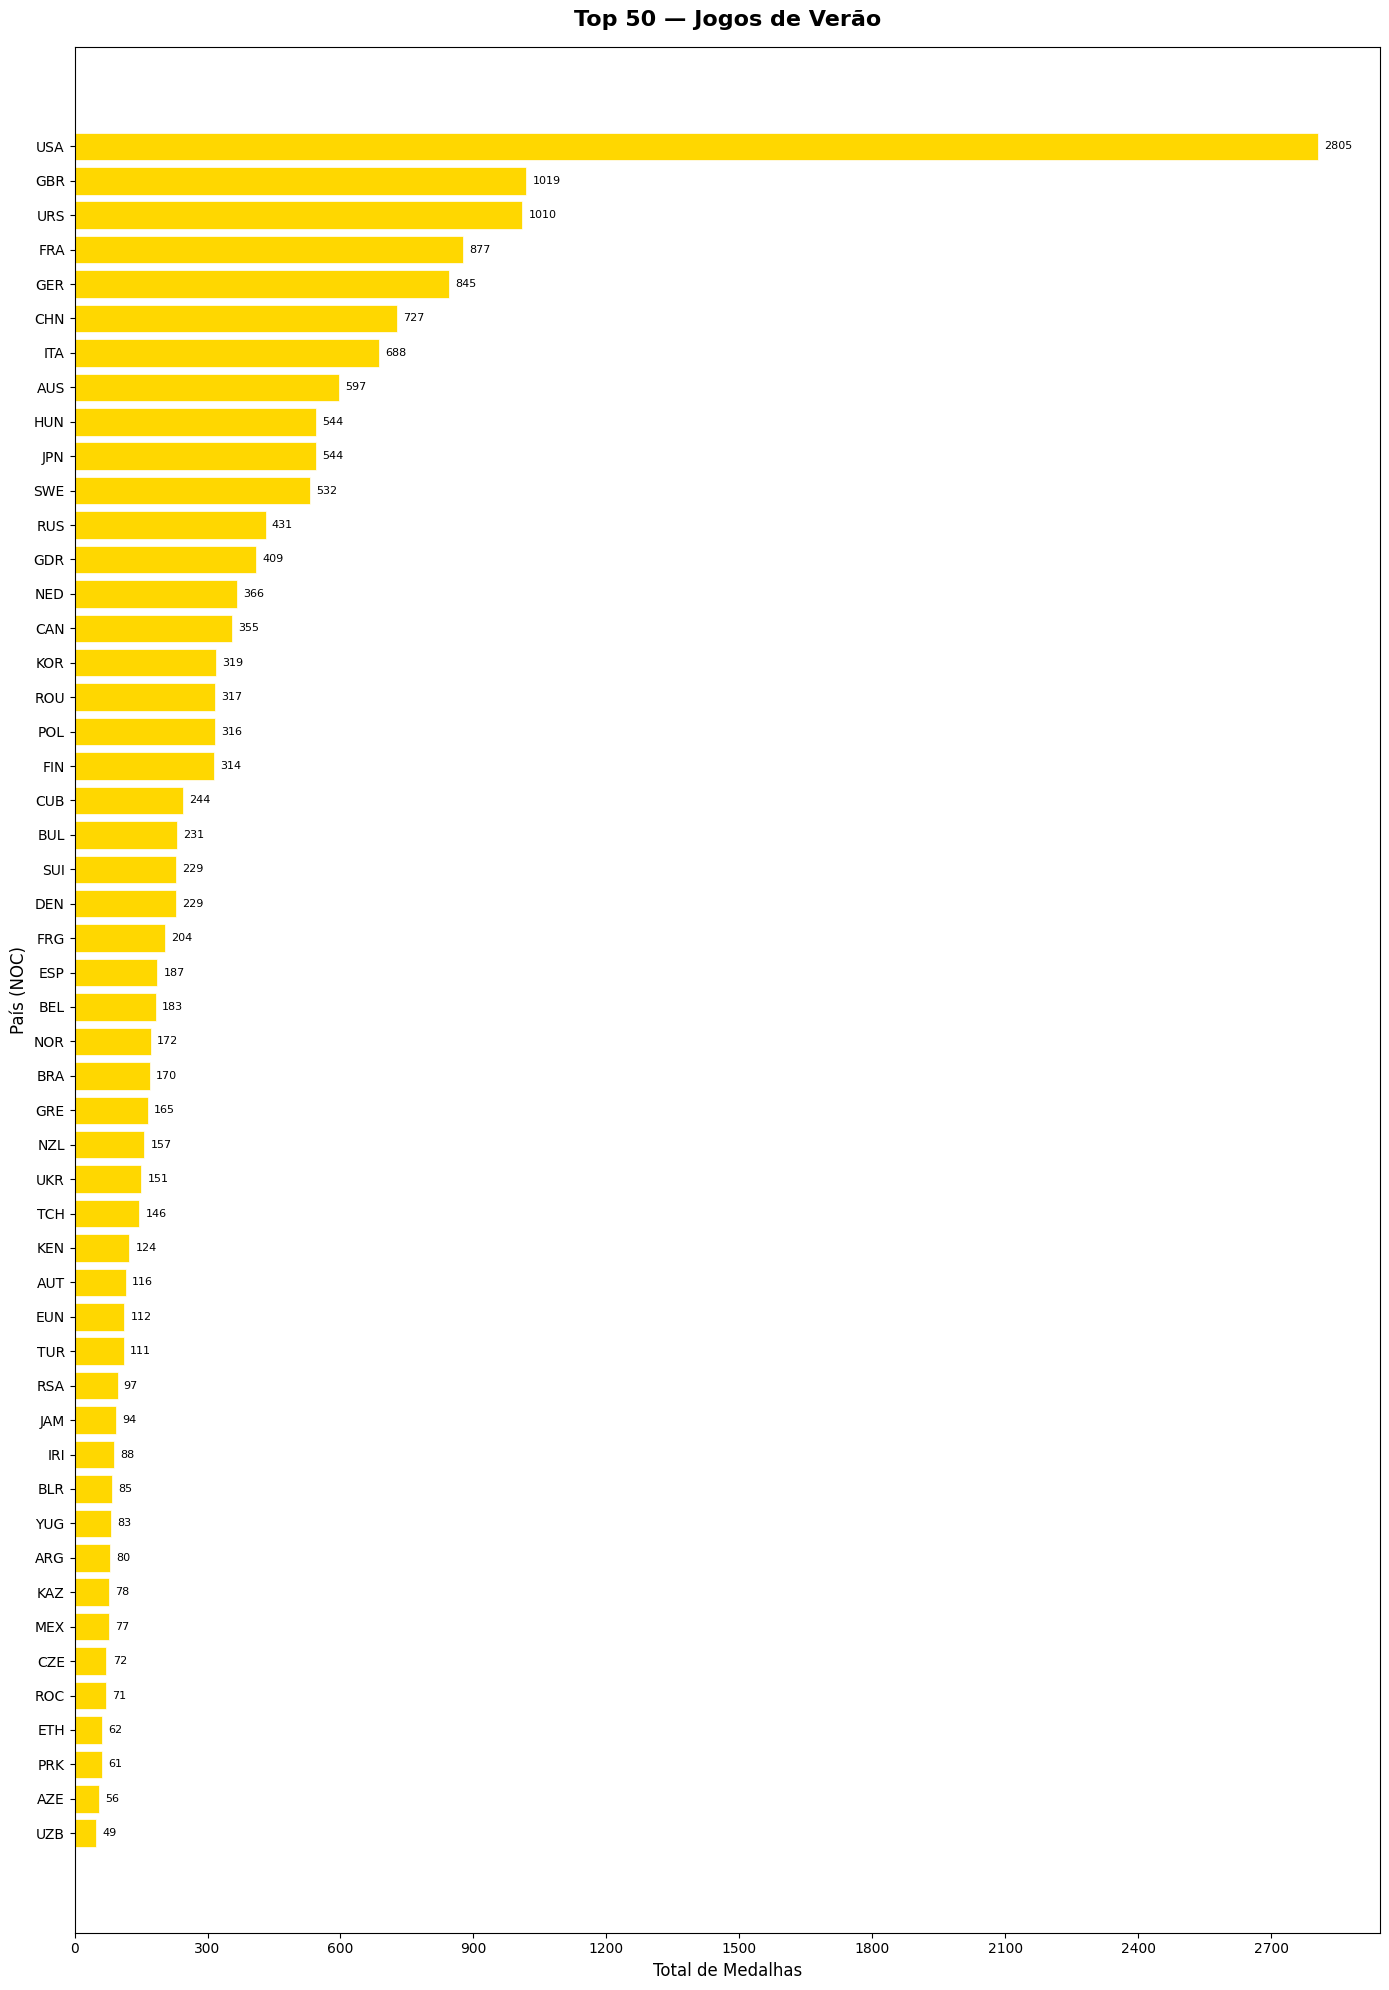

Gráfico salvo: Top_50__Jogos_de_Verão.png


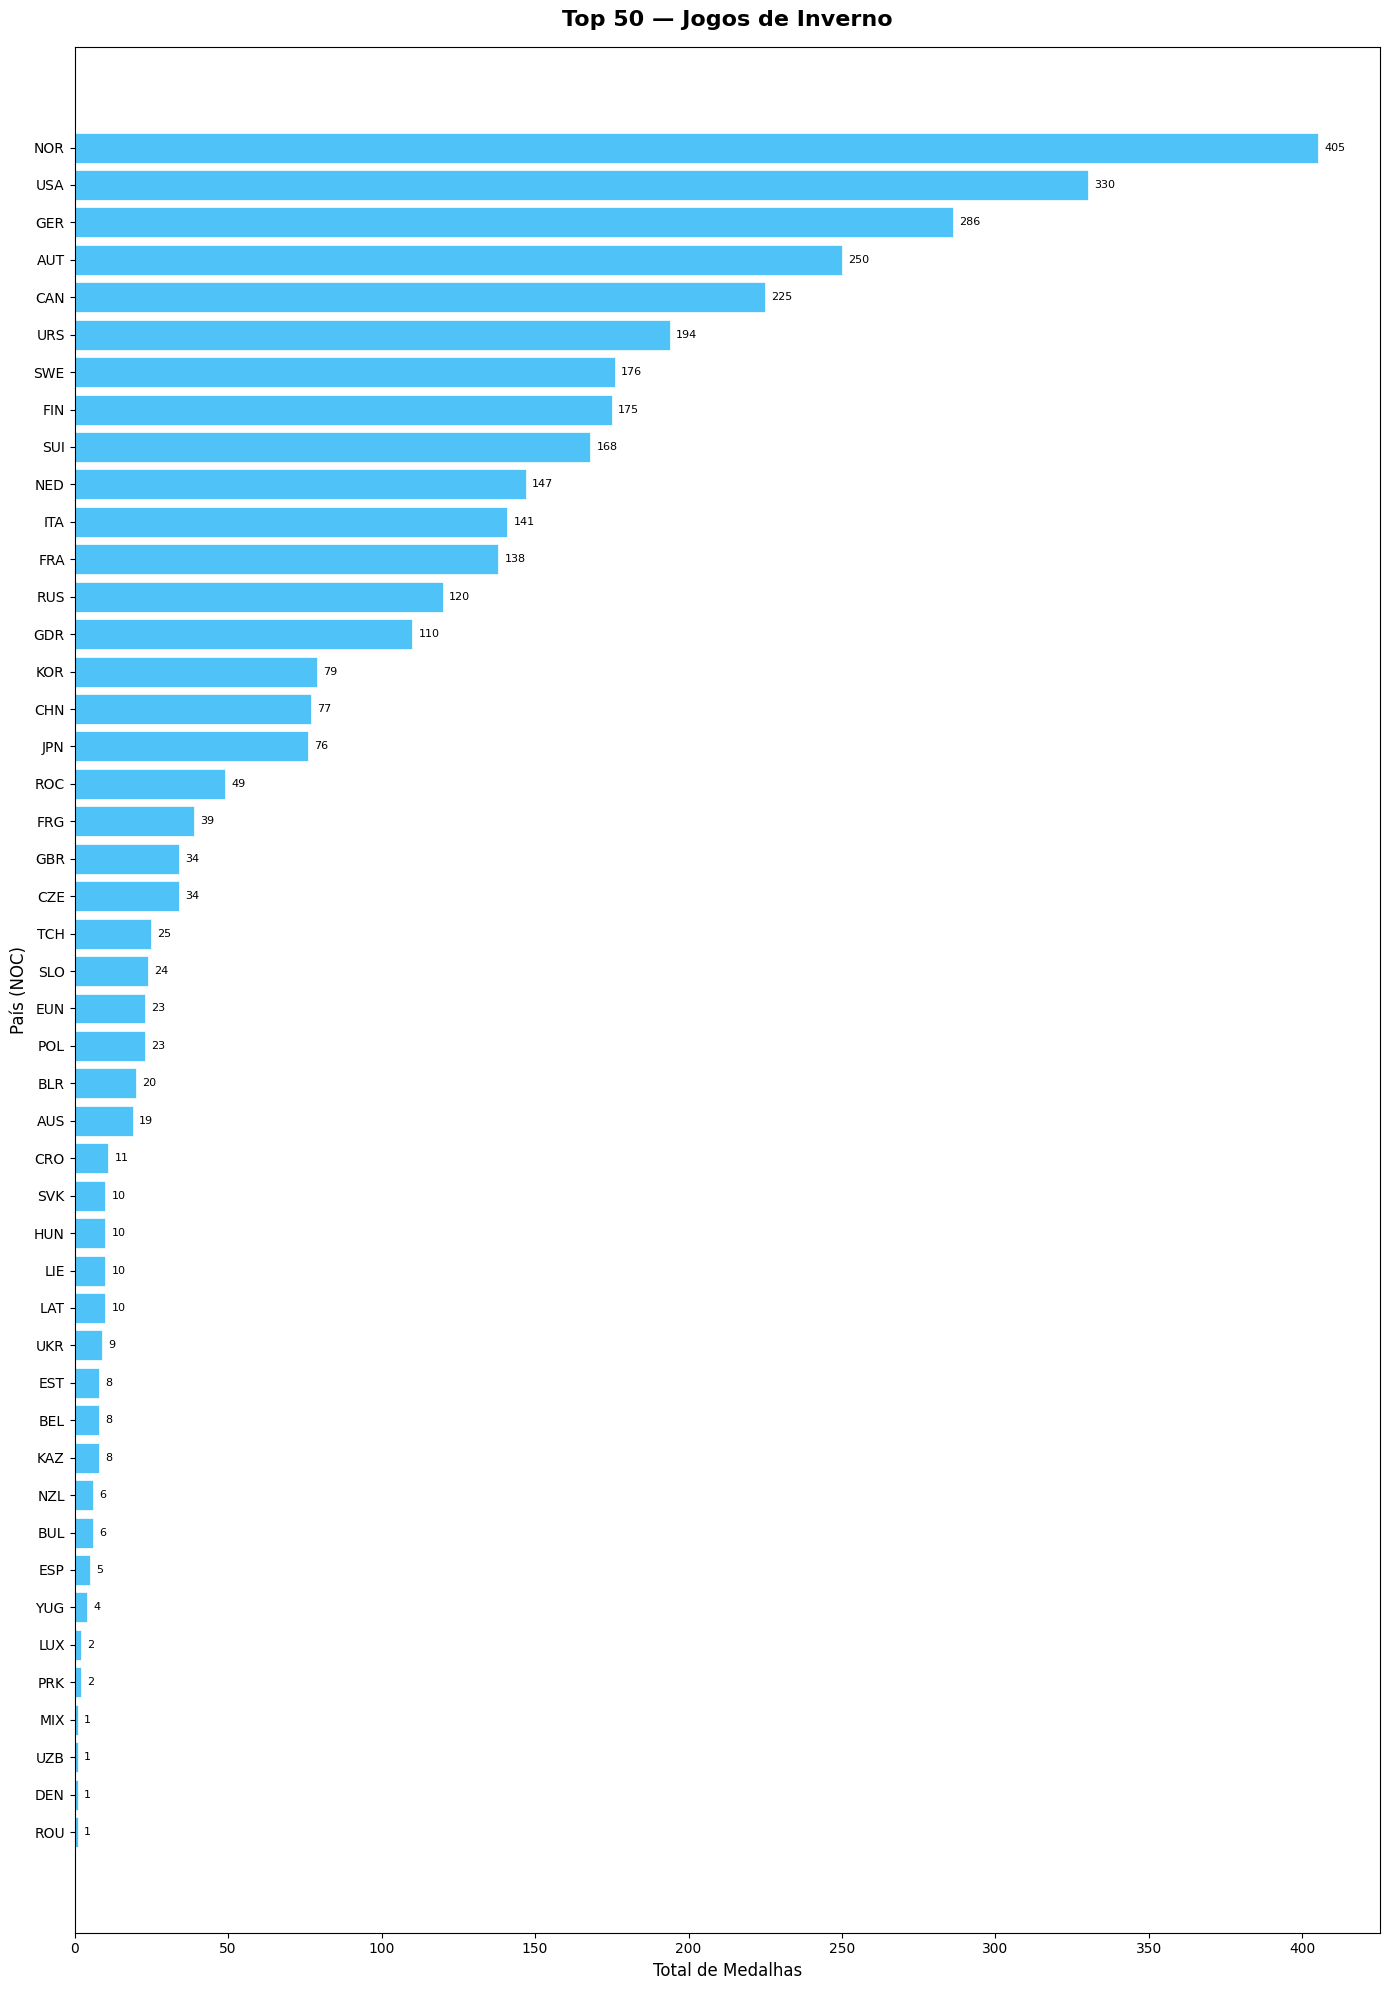

Gráfico salvo: Top_50__Jogos_de_Inverno.png


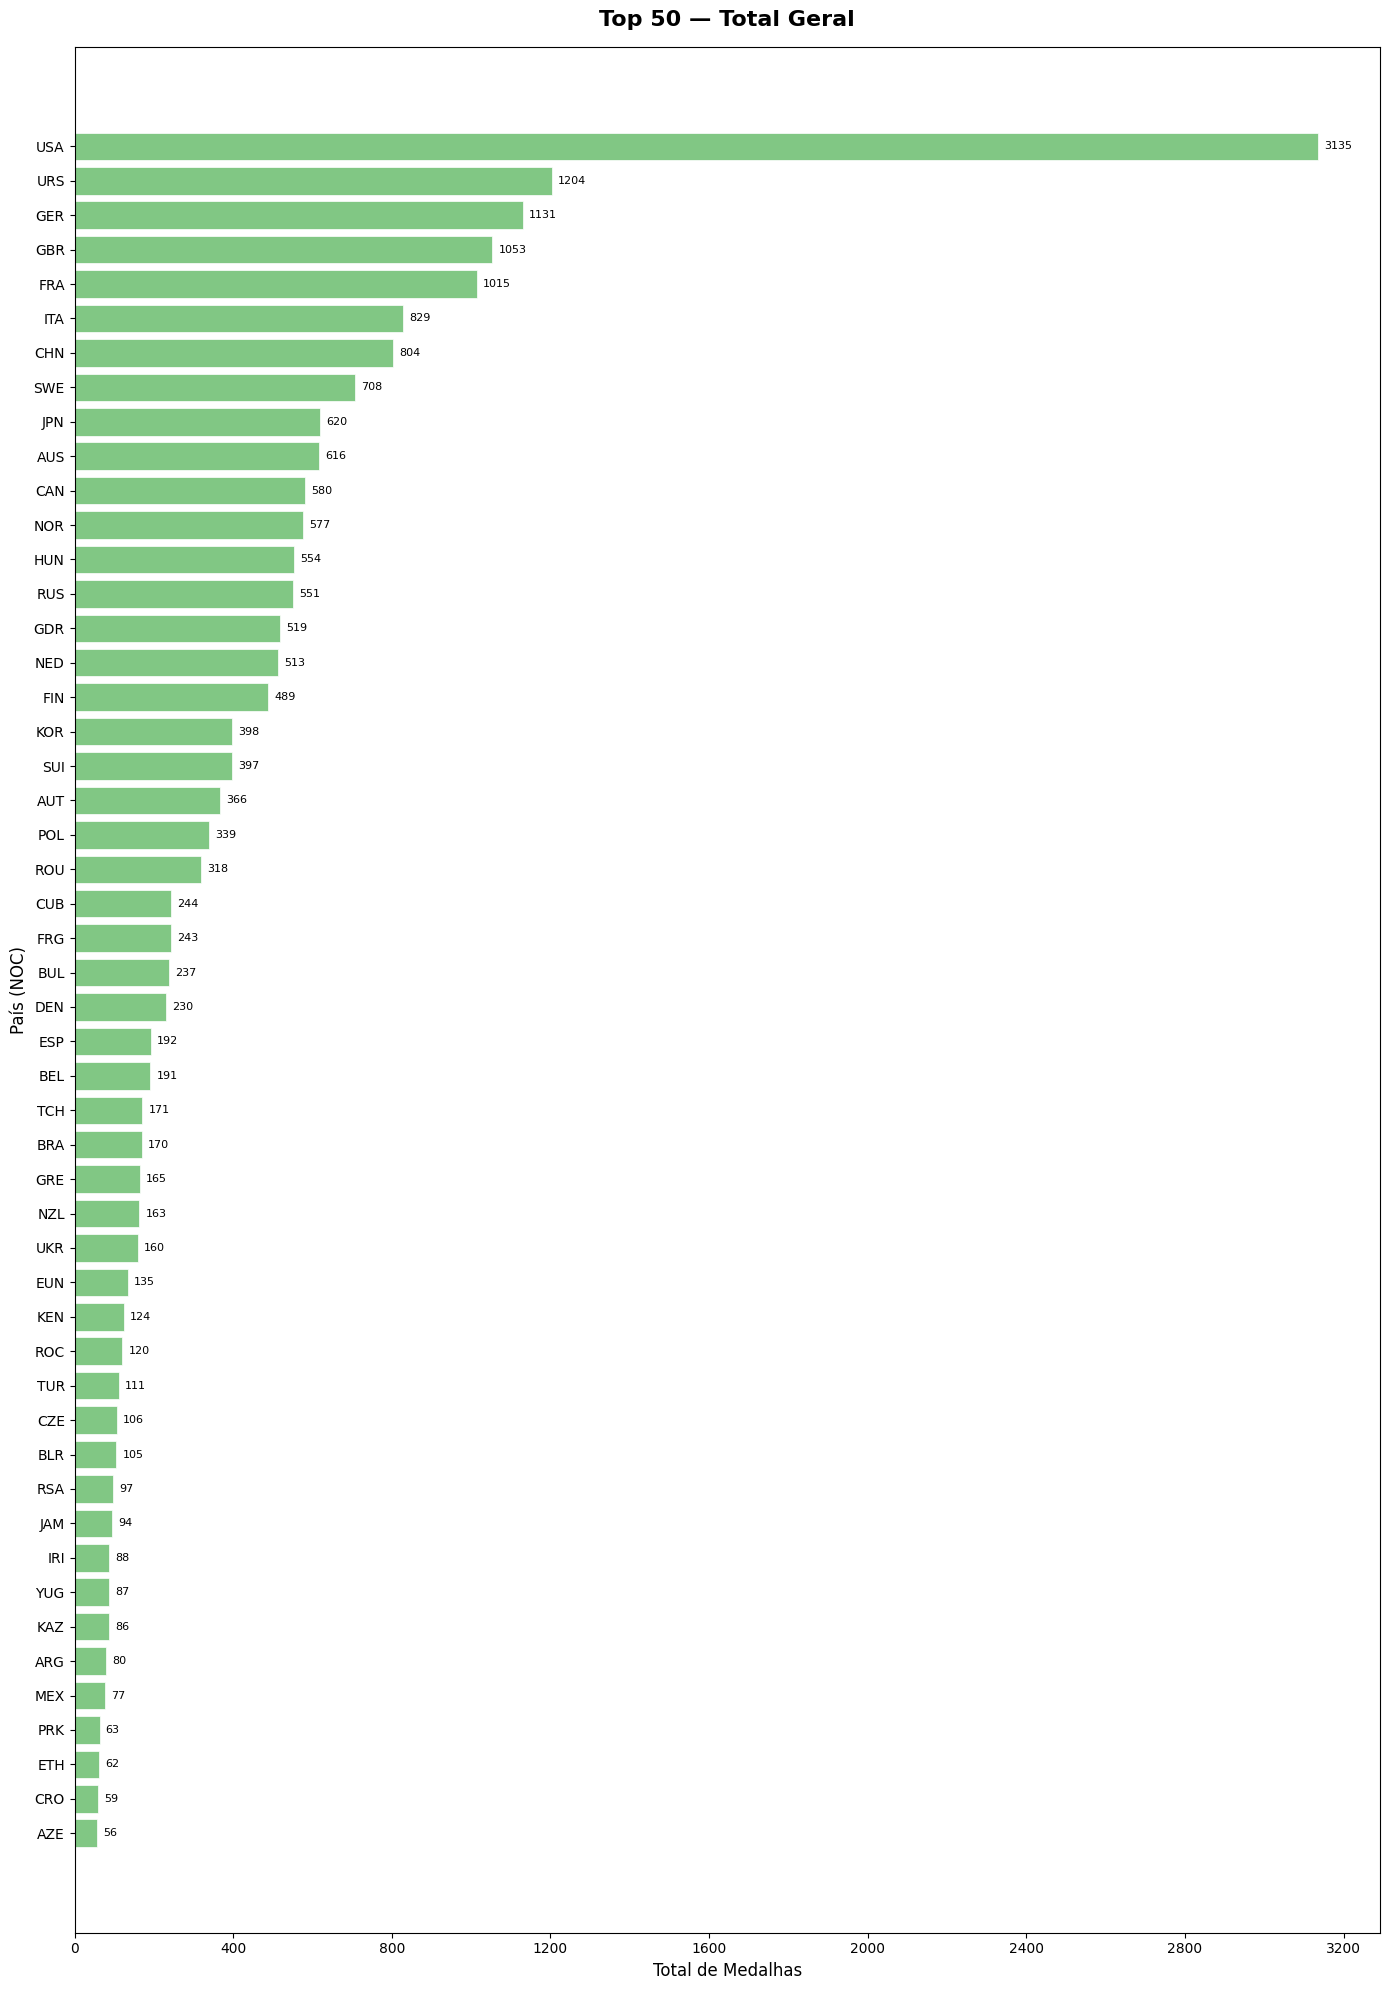

Gráfico salvo: Top_50__Total_Geral.png


In [8]:

# CÉLULA 8 — Gráficos Top 50 por categoria (1.2)

def plot_top50(df_table, title, color):
    top50 = df_table.head(50).copy()
    top50 = top50.iloc[::-1]  # inverte para o maior ficar no topo

    fig, ax = plt.subplots(figsize=(14, 20))
    bars = ax.barh(top50['NOC'], top50['Total'], color=color, edgecolor='white', linewidth=0.5)

    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Total de Medalhas', fontsize=12)
    ax.set_ylabel('País (NOC)', fontsize=12)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    for bar in bars:
        w = bar.get_width()
        ax.text(w + max(top50['Total']) * 0.005,
                bar.get_y() + bar.get_height() / 2,
                str(int(w)), va='center', fontsize=8)

    plt.tight_layout()
    nome_arquivo = title.replace(' ', '_').replace('—', '').strip() + '.png'
    plt.savefig(nome_arquivo, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Gráfico salvo: {nome_arquivo}")

plot_top50(tbl_summer, 'Top 50 — Jogos de Verão',  '#FFD700')
plot_top50(tbl_winter, 'Top 50 — Jogos de Inverno', '#4FC3F7')
plot_top50(tbl_total,  'Top 50 — Total Geral',       '#81C784')

In [9]:

# CÉLULA 9 — (Opcional) Exportar tabelas como CSV

tbl_summer.to_csv('medalhas_verao.csv',   index=False)
tbl_winter.to_csv('medalhas_inverno.csv', index=False)
tbl_total.to_csv('medalhas_total.csv',    index=False)
print("Arquivos exportados!")

Arquivos exportados!


In [10]:

# CÉLULA 7 ATUALIZADA — Tabela no formato Wikipédia

def make_wikipedia_table(df_agg, label=''):
    """
    Gera tabela no formato Wikipedia com colunas:
    Edições | Verão (O/P/B/T) | Inverno (O/P/B/T) | Total Geral (O/P/B/T)
    """
    # Separar verão e inverno
    summer = (
        df_agg[df_agg['Season'] == 'Summer']
        .groupby('NOC')[['Gold','Silver','Bronze','Total']].sum()
        .rename(columns={'Gold':'S_Gold','Silver':'S_Silver','Bronze':'S_Bronze','Total':'S_Total'})
    )
    winter = (
        df_agg[df_agg['Season'] == 'Winter']
        .groupby('NOC')[['Gold','Silver','Bronze','Total']].sum()
        .rename(columns={'Gold':'W_Gold','Silver':'W_Silver','Bronze':'W_Bronze','Total':'W_Total'})
    )

    # Juntar num único dataframe
    df_wiki = summer.join(winter, how='outer').fillna(0).astype(int)

    # Calcular totais gerais
    df_wiki['T_Gold']   = df_wiki['S_Gold']   + df_wiki['W_Gold']
    df_wiki['T_Silver'] = df_wiki['S_Silver']  + df_wiki['W_Silver']
    df_wiki['T_Bronze'] = df_wiki['S_Bronze']  + df_wiki['W_Bronze']
    df_wiki['T_Total']  = df_wiki['S_Total']   + df_wiki['W_Total']

    # Ordenar por total geral decrescente (depois ouro, prata como desempate)
    df_wiki = df_wiki.sort_values(
        ['T_Total','T_Gold','T_Silver'], ascending=False
    ).reset_index()

    df_wiki.index += 1  # ranking começa em 1

    # Renomear colunas para exibição
    df_wiki.columns = pd.Index([
        'País',
        '☀️ Ouro', '☀️ Prata', '☀️ Bronze', '☀️ Total',
        '❄️ Ouro', '❄️ Prata', '❄️ Bronze', '❄️ Total',
        'T Ouro',  'T Prata',  'T Bronze',  'T Total'
    ])

    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(df_wiki.head(20).to_string())
    return df_wiki

tbl_wiki = make_wikipedia_table(df_agg, label='Quadro de Medalhas — Formato Wikipédia')


  Quadro de Medalhas — Formato Wikipédia
   País  ☀️ Ouro  ☀️ Prata  ☀️ Bronze  ☀️ Total  ❄️ Ouro  ❄️ Prata  ❄️ Bronze  ❄️ Total  T Ouro  T Prata  T Bronze  T Total
1   USA     1122       891        792      2805      113       122         95       330    1235     1013       887     3135
2   URS      395       319        296      1010       78        57         59       194     473      376       355     1204
3   GER      255       286        304       845      112       104         70       286     367      390       374     1131
4   GBR      314       356        349      1019       12         5         17        34     326      361       366     1053
5   FRA      262       292        323       877       41        42         55       138     303      334       378     1015
6   ITA      241       214        233       688       42        43         56       141     283      257       289      829
7   CHN      303       226        198       727       22        32         23        77   